In [1]:
## parameters for experiment
N_BLOCK = 5
LR = 0.001

OUTPUT_DIR = '20260122-Stage2Optimized-test2'
STAGE1_MODEL_DIR = '20251202-CorrectionNetworkTestv2.2'  # Directory containing pre-trained Stage-1 model

RANDOM_SEED = 42

IN_CHANNEL = 1

AUGMENTED = True
AUGMENTATION = 30

CROSS_VAL = True
N_SPLIT = 4

In [2]:
## import libraries
from numpy.core.numeric import NaN
from MCtool.RFilter import gray
from genericpath import exists
from matplotlib import image
import math
import sys
import time

import cv2
from matplotlib import pyplot as plt
from tensorflow.python.keras.backend import dtype
from DeepLearning import LearnAndTest
from Rpkg.Rfund.InputFeature import InputFeature
import datetime
import os
import gc
import tensorflow as tf
import random
import numpy as np
import pandas as pd

from Rpkg.Rfund import ReadFile, WriteFile
from Rpkg.Rmodel import Unet, Mnet

import Filtering

import torch
from torch import nn

import DeepLearning
from tensorflow.keras.optimizers import Adam

from Rpkg.Rfund.InputFeature import InputFeature
from Rpkg.Rfund import ReadFile, WriteFile
from Rpkg.Rmodel import Unet, Mnet

from MCtool import RFilter, resultEval
from DeepLearning import save_eval_result

import numpy as np
import cv2
import torch
from transformations import ComposeDouble, FunctionWrapperDouble, create_dense_target, normalize_01
from customdatasets import SegmentationDataSet1
from customdatasets import SegmentationDataSet4
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import pathlib
from skimage.transform import resize

from unet import UNet
from unetNew import UNetC
from trainer import Trainer
from sklearn.model_selection import StratifiedKFold, train_test_split

2026-01-23 07:42:19.845306: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 07:42:21.156617: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
## random seed config
import torch
import numpy as np
import random

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
## cuda and pytorch stats
print('PyTorch Version installed: ' + torch.__version__)
print('CUDA version associated with PyTorch version: ' + torch.version.cuda)
print('Version of cuDNN (CUDA Deep Neural Network library) being used by PyTorch' + str(torch.backends.cudnn.version()))
print('CUDA is available: ' + str(torch.cuda.is_available()))
print('Number of GPUs compatible with CUDA:' + str(torch.cuda.device_count()))
print('Name of the GPU at index 0: '  + str(torch.cuda.get_device_name(0)))
print('Current CUDA device index: '  + str(torch.cuda.current_device()))

PyTorch Version installed: 2.3.0+cu121
CUDA version associated with PyTorch version: 12.1
Version of cuDNN (CUDA Deep Neural Network library) being used by PyTorch8902
CUDA is available: True
Number of GPUs compatible with CUDA:1
Name of the GPU at index 0: NVIDIA GeForce RTX 2080 Ti
Current CUDA device index: 0


In [5]:
## file_names_with_prefix
def file_names_with_prefix(directory_path, prefix):
    file_names_without_extension = []
    for filename in os.listdir(directory_path):
        if os.path.isfile(os.path.join(directory_path, filename)):
            if filename.startswith(prefix):
                name_without_extension, _ = os.path.splitext(filename)
                file_names_without_extension.append(name_without_extension)
    
    sorted_file_names = sorted(
        file_names_without_extension,
        key=lambda x: (x.split('-')[0], int(x.split('-')[1]))
    )
    return sorted_file_names

In [6]:
## paths config
import pathlib
from pathlib import Path

root_dir = Path(pathlib.Path.cwd())
date_str = OUTPUT_DIR

data_dir = str(root_dir / "img_1006t/original")
feature_dir = str(root_dir / "img_1006t/feature") 
labeled_dir = str(root_dir / "img_1006t/labeled")

augmented_labeled_dir = str(root_dir / "img_1006t/labelAug")
augmented_data_dir = str(root_dir / "img_1006t/originalAug")
augmented_feature_dir = str(root_dir / "img_1006t/featureAug")

annealing_img_dir = str(root_dir / "img_1006/original")
result_dir = str(root_dir / "result" / date_str)
test_result_dir = str(root_dir / "result_test" / date_str)

Path(result_dir).mkdir(parents=True, exist_ok=True)
Path(test_result_dir).mkdir(parents=True, exist_ok=True)

print('Root directory: ' + str(root_dir))
print('Data directory (original dir): ' + str(data_dir))
print('Feature img directory: ' + str(feature_dir))
print('Labeled img directory: ' + str(labeled_dir))
print('Result directory: ' + str(result_dir))
print('Test result directory: ' + str(test_result_dir))

input_train = []
input_name_val = []
annealing_input_name = []
test_input_name = []

len_train = len(input_train)
len_val = len(input_name_val)
len_test = len(test_input_name)
len_annealing = len(annealing_input_name)

Root directory: /home/eric/Documents/cervicalResearchIIP
Data directory (original dir): /home/eric/Documents/cervicalResearchIIP/img_1006t/original
Feature img directory: /home/eric/Documents/cervicalResearchIIP/img_1006t/feature
Labeled img directory: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled
Result directory: /home/eric/Documents/cervicalResearchIIP/result/20260122-Stage2Optimized-test2
Test result directory: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2


In [7]:
## filters
inputfeature_list = list(map(str, InputFeature))
#inputfeature_list = ['CLA_']
print(inputfeature_list)
feature_num = len(inputfeature_list)
print(feature_num)

['GRY_', 'NML1', 'NML2', 'NML3', 'TOP1', 'TOP2', 'TOP3', 'TOP4', 'SBLX', 'SBLY', 'SBLM', 'SBLD', 'SBL1', 'SBL2', 'SBL3', 'SBL4', 'LPL1', 'LPL2', 'MEA1', 'MEA2', 'GAU1', 'GAU2', 'MED1', 'MED2', 'LBP1', 'LBP2', 'LBP3', 'ETC1', 'ETC2', 'STC1', 'STC2', 'HGF_', 'NGP_', 'POS1', 'POS2', 'POS3', 'SOL_', 'EMB1', 'EMB2', 'EMB3', 'KNN1', 'KNN2', 'BLT1', 'BLT2', 'OOO_', 'CLA_']
46


In [8]:
## createweightimage read by images
def CreateWeightImage(input_number, augmentation=False):
    print("Creating image arrays...")
    label_dataset = []
    arrDataset = []
    for i in input_number:
        if augmentation:
            label_path = os.path.join(augmented_labeled_dir, str(AUGMENTATION) + "aug/" , f"{i}.png")
        else:
            label_path = os.path.join(labeled_dir, f"{i}.png")
        input_originallabel = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        label_dataset.append(input_originallabel)

    print("Number of label images:", len(label_dataset))

    for i in input_number:
        dataset_img = np.zeros((256, 256, feature_num), dtype=np.float32)
        for m in range(feature_num):
            if augmentation:
                feature_img_path = os.path.join(augmented_feature_dir, str(AUGMENTATION) + "aug/" , str(i), f"{inputfeature_list[m]}.png")
            else:
                feature_img_path = os.path.join(feature_dir, str(i), f"{inputfeature_list[m]}.png")
            input_featureimg = cv2.imread(feature_img_path, cv2.IMREAD_GRAYSCALE)
            dataset_img[:, :, m] = input_featureimg

        arrDataset.append(dataset_img)

    arrDataset = np.array(arrDataset)
    print("Completed creating image arrays:")
    print("Dataset shape ", arrDataset.shape)
    print("Label image shape ", np.shape(label_dataset))
    print()

    return arrDataset, label_dataset

In [9]:
## createweightimagenew read paths only
def CreateWeightImageNew(input_numbers, augmentation=False):
    print("Creating image paths...")
    label_paths = []
    feature_paths = []

    for i in input_numbers:
        if augmentation:
            label_path = os.path.join(augmented_labeled_dir, str(AUGMENTATION) + "aug/", f"{i}.png")
        else:
            label_path = os.path.join(labeled_dir, f"{i}.png")
        label_paths.append(label_path)

        feature_img_paths = []
        for feature_name in inputfeature_list:
            if augmentation:
                feature_img_path = os.path.join(augmented_feature_dir, str(AUGMENTATION) + "aug/", str(i), f"{feature_name}.png")
            else:
                feature_img_path = os.path.join(feature_dir, str(i), f"{feature_name}.png")
            feature_img_paths.append(feature_img_path)

        feature_paths.append(feature_img_paths)

    print(f"Processed {len(label_paths)} label paths and {len(feature_paths)} feature paths.")
    return feature_paths, label_paths

In [10]:
## minor irrelevant function
def print_model_shapes(model, input_tensor):
    def forward_hook(module, input, output):
        print(f"Layer: {module.__class__.__name__}")
        print(f"Input shape: {str(input[0].shape)}")
        print(f"Output shape: {str(output.shape)}")
        print("-----------------------")

    hooks = []
    for layer in model.children():
        hook = layer.register_forward_hook(forward_hook)
        hooks.append(hook)

    print("Model Architecture:")
    print(model)

    with torch.no_grad():
        model(input_tensor)

    for hook in hooks:
        hook.remove()

In [11]:
## preprocess and postprocess function
def preprocess(img: np.ndarray):
    img = np.moveaxis(img, -1, 0)
    img = normalize_01(img)
    img = np.expand_dims(img, axis=0)
    img = img.astype(np.float32)
    return img

def postprocess(img: torch.tensor):
    img = torch.argmax(img, dim = 1)
    img = img.cpu().numpy().astype(np.uint8)
    img = np.squeeze(img)
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
        img = img[:, :, ::-1]
    elif img.shape[0] == 1:
        img = np.squeeze(img, 0)
    return img

In [12]:
def record_results(training_losses, validation_losses, lr_rates, learning_curve, model, fold, input_dataset_val, input_name_val, type_number, device, model_n = "unet2"):
    
    assert len(training_losses) == len(validation_losses) == len(lr_rates), \
        "Lengths of training, validation losses, and learning rates must match."

    df = pd.DataFrame({
        "Epoch": list(range(1, len(training_losses) + 1)),
        "Training_Loss": training_losses,
        "Validation_Loss": validation_losses,
        "Learning_Rate": lr_rates
    })

    df.to_csv(test_result_dir + f"/{model_n}_fold{fold}_log.csv", index = False)
    learning_curve.savefig(test_result_dir + f"/{model_n}_fold{fold}_learningcurve.png")
    
    print("***************************")

    model_dir = os.path.join("model", date_str)
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
    model_name = f"{model_n}_fold_{fold}.pt"
    model_path = os.path.join(model_dir, model_name)
    torch.save(model.state_dict(), model_path)
    print(f"modelname:{model_name}を保存しました")
    
    model_weights = torch.load(model_path)
    model.load_state_dict(model_weights)

In [13]:
## learn_ea function training logic - STAGE-2 ONLY with f1+f2 (109 filters)
from customdatasets import SegmentationDataSet0
from customdatasets import SegmentationDataSet1
from customdatasets import SegmentationDataSet5
from torch.utils.data import DataLoader

def Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
             type_number, fold=0, next_model=False, model_n="unet2", inChannels=57,
             stage1_model_path=None, stage1_model_loaded=None):
    """
    Stage-2 only training using pre-trained Stage-1 model.
    Generates f1 (Stage-1 probs, 11 channels) + f2 (46-filter conv on features).
    Final input: concat(f1, f2) = 11 + 46 = 57 channels
    """
    print("*************************Stage-2 Training (No Stage-1 Training)*************************")
    
    # Load pre-trained Stage-1 model if not already loaded
    if stage1_model_loaded is None and stage1_model_path is not None:
        print(f"Loading pre-trained Stage-1 model from: {stage1_model_path}")
        stage1_model = UNet(in_channels=IN_CHANNEL,
                           out_channels=11,
                           n_blocks=N_BLOCK,
                           start_filters=32,
                           activation='relu',
                           normalization='instance',
                           conv_mode='same',
                           dim=2)
        stage1_model.load_state_dict(torch.load(stage1_model_path))
        stage1_model_loaded = stage1_model
    
    if stage1_model_loaded is None:
        raise ValueError("stage1_model_path or stage1_model_loaded must be provided")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create 46-filter convolution layer for f2 generation
    f2_conv = nn.Conv2d(in_channels=46, out_channels=46, kernel_size=3, padding=1).to(device)
    
    # Get Stage-1 outputs (f1) and 46-filter outputs (f2) for training data
    print("\nGenerating f1 (Stage-1 probs) and f2 (46-filter tensor) for training data...")
    stage1_model_loaded.eval()
    stage1_model_loaded.to(device)
    
    stage1_train_f1 = []
    stage1_train_f2 = []
    with torch.no_grad():
        for idx, img in enumerate(input_dataset):
            img_preprocessed = preprocess(img)  # [1, 46, 256, 256]
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # f1: Stage-1 UNet output (11 channels) - use only first channel
            output_f1 = stage1_model_loaded(img_tensor[:, :1, :, :])  # [1, 11, 256, 256]
            stage1_train_f1.append(output_f1.squeeze(0).cpu().numpy())
            
            # f2: 46-filter convolution on all 46 channels (46 channels)
            output_f2 = f2_conv(img_tensor)  # [1, 46, 256, 256]
            stage1_train_f2.append(output_f2.squeeze(0).cpu().numpy())
    
    stage1_train_f1 = np.array(stage1_train_f1)  # [N, 11, 256, 256]
    stage1_train_f2 = np.array(stage1_train_f2)  # [N, 46, 256, 256]
    
    # Concatenate f1 + f2 (11 + 46 = 57 channels)
    stage1_train_outputs = np.concatenate((stage1_train_f1, stage1_train_f2), axis=1)  # [N, 57, 256, 256]
    print(f"f1 training shape: {stage1_train_f1.shape}")
    print(f"f2 training shape: {stage1_train_f2.shape}")
    print(f"Concatenated training shape: {stage1_train_outputs.shape}")
    
    # Get Stage-1 outputs (f1) and 46-filter outputs (f2) for validation data
    print("Generating f1 and f2 for validation data...")
    stage1_val_f1 = []
    stage1_val_f2 = []
    with torch.no_grad():
        for idx, img in enumerate(input_dataset_val):
            img_preprocessed = preprocess(img)
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # f1: Stage-1 UNet output (11 channels) - use only first channel
            output_f1 = stage1_model_loaded(img_tensor[:, :1, :, :])  # [1, 11, 256, 256]
            stage1_val_f1.append(output_f1.squeeze(0).cpu().numpy())
            
            # f2: 46-filter convolution on all 46 channels (46 channels)
            output_f2 = f2_conv(img_tensor)  # [1, 46, 256, 256]
            stage1_val_f2.append(output_f2.squeeze(0).cpu().numpy())
    
    stage1_val_f1 = np.array(stage1_val_f1)  # [M, 11, 256, 256]
    stage1_val_f2 = np.array(stage1_val_f2)  # [M, 46, 256, 256]
    
    # Concatenate f1 + f2 (11 + 46 = 57 channels)
    stage1_val_outputs = np.concatenate((stage1_val_f1, stage1_val_f2), axis=1)  # [M, 57, 256, 256]
    print(f"f1 validation shape: {stage1_val_f1.shape}")
    print(f"f2 validation shape: {stage1_val_f2.shape}")
    print(f"Concatenated validation shape: {stage1_val_outputs.shape}")
    
    # Create datasets from concatenated f1+f2 for Stage-2 training
    print("\n--- Creating Stage-2 DataLoaders ---")
    dataset_train2 = SegmentationDataSet0(
        inputs=stage1_train_outputs,
        targets=label_dataset,
        transform=None
    )

    dataset_val = SegmentationDataSet0(
        inputs=stage1_val_outputs,
        targets=label_dataset_val,
        transform=None
    )

    dataloader_training2 = DataLoader(dataset=dataset_train2,
                                        batch_size=2,
                                        shuffle=True)
    
    dataloader_val = DataLoader(dataset=dataset_val,
                                batch_size=2,
                                shuffle=False)
    
    batch = next(iter(dataloader_training2))
    x, y = batch
    print("Stage-2 batch shapes - x: ", x.shape)
    print("Stage-2 batch shapes - y: ", y.shape)
    print("x.min(), x.max() = ", x.min(), x.max())
    print("torch.unique(y) = ", torch.unique(y))

    # Stage-2 UNet training
    from unet import UNet
    from trainer2 import Trainer2 
    from customLoss import DiceLoss

    model = UNetC(in_channels=inChannels,
                 out_channels=11,
                 n_blocks=N_BLOCK, 
                 start_filters=32,
                 activation='relu',
                 normalization='instance',
                 conv_mode='same',
                 dim=2).to(device)
    
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    print("\n--- Starting Stage-2 Training ---")
    trainer = Trainer2(model=model, 
                       device=device, 
                       criterion=criterion, 
                       optimizer=optimizer, 
                       training_DataLoader=dataloader_training2,
                       validation_DataLoader=dataloader_val, 
                       lr_scheduler=None, 
                       epochs=200,
                       fold=fold,
                       notebook=True)
  
    print("=======Starting Stage-2 Training======")
    training_losses, validation_losses, lr_rates, learning_curve, train_preds, train_targets, val_preds, val_targets = trainer.run_trainer()
    
    def safe_cat(tensors):
        if isinstance(tensors, torch.Tensor):
            return tensors
        if len(tensors) == 0:
            raise RuntimeError("No predictions collected.")
        return torch.cat(tensors, dim=0)

    train_preds = safe_cat(train_preds)
    train_targets = safe_cat(train_targets)
    val_preds = safe_cat(val_preds)
    val_targets = safe_cat(val_targets)

    record_results(training_losses, validation_losses, lr_rates, learning_curve, model, fold, 
                   stage1_val_outputs, input_name_val, type_number, device, model_n)
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    print("\n=======Stage-2 Training Complete======\n")

In [14]:
## dice calculation
import statistics

def cal_DiceMulitple(dir, input_name):
    Dice = [0] * 11
    Count1 = [0] * 11
    Count2 = [0] * 11
    Count3 = [0] * 11
    
    for index in range(len(input_name)):
        print('index = ', index)

        img1 = cv2.imread(dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(labeled_dir + '/' + input_name[index] + ".png", cv2.IMREAD_GRAYSCALE)
        print("予測画像:", dir  + '/' + input_name[index] + ".png")
        print("テストラベル:", labeled_dir + '/' + input_name[index] + ".png")
        unique_label1 = np.unique(img1)
        unique_label2 = np.unique(img2)
        
        for n in range(256):
            for l in range(256):
                value1 = img1[n,l]
                Count1[value1] += 1
                value2 = img2[n,l]
                Count2[value2] += 1                    
                if(value1 == value2):
                    Count3[value1] += 1 
    
    for i in range(11):
        if(Count1[i]+Count2[i] != 0):
            Dice[i] = (2*Count3[i])/(Count1[i] + Count2[i])
    
    Dice.append(statistics.mean(Dice[1:]))
    print('Count1 = ', Count1)
    print('Count2 = ', Count2)
    print('Count3 = ', Count3)
    print('Dice = ', Dice)

    return Dice

In [15]:
## mConv_predict test function
import statistics
from inference import predict
from denseCRF import noiseReduction

def mConv_predict(test_input_name, fold=0, stage1_model_path=None):
    print("*************************************Test*************************************")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ---------- Load Models ----------
    model_dir = os.path.join("model", date_str)
    model2_path = os.path.join(model_dir, f"unet2_fold_{fold}.pt")
    
    if stage1_model_path is None:
        model1_path = os.path.join(model_dir, f"unet1_fold_{fold}.pt")
    else:
        model1_path = stage1_model_path

    # Load Stage-1 model
    stage1_model = UNet(in_channels=IN_CHANNEL,
            out_channels=11,
            n_blocks=N_BLOCK,
            start_filters=32,
            activation='relu',
            normalization='instance',
            conv_mode='same',
            dim=2).to(device)
    stage1_model.load_state_dict(torch.load(model1_path))
    stage1_model.eval()

    # Create f2 conv
    f2_conv = nn.Conv2d(in_channels=46, out_channels=46, kernel_size=3, padding=1).to(device)
    
    model2 = UNetC(in_channels=57,
            out_channels=11,
            n_blocks=N_BLOCK,
            start_filters=32,
            activation='relu',
            normalization='instance',
            conv_mode='same',
            dim=2).to(device)

    model2.load_state_dict(torch.load(model2_path))
    model2.eval()

    # ---------- Load Test ----------
    test_input_dataset, _ = CreateWeightImage(test_input_name)

    output_stage2 = []

    # ---------- Generate f1 + f2 and Stage-2 ----------
    with torch.no_grad():
        for img in test_input_dataset:
            img_preprocessed = preprocess(img)  # [1, 46, 256, 256]
            img_tensor = torch.from_numpy(img_preprocessed).to(device)
            
            # f1: Stage-1 probs (11 channels)
            output_f1 = stage1_model(img_tensor[:, :1, :, :])  # [1, 11, 256, 256]
            
            # f2: conv on all 46 channels (46 channels)
            output_f2 = f2_conv(img_tensor)  # [1, 46, 256, 256]
            
            # Concat f1 + f2 (57 channels)
            concat_input = torch.cat((output_f1, output_f2), dim=1)  # [1, 57, 256, 256]
            
            # Stage-2 prediction
            out2 = model2(concat_input)
            pred2 = torch.argmax(out2, 1).squeeze().cpu().numpy()
            output_stage2.append(pred2)

    # ---------- Save results ----------
    fold_dir = os.path.join(test_result_dir, f"fold{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    unet2_dir = os.path.join(fold_dir, "unet2")
    os.makedirs(unet2_dir, exist_ok=True)

    for i, name in enumerate(test_input_name):
        cv2.imwrite(os.path.join(unet2_dir, f"{name}.png"), output_stage2[i])

    # ---------- Dice + CRF ----------
    Dice2 = cal_DiceMulitple(unet2_dir, test_input_name)
    pd.DataFrame(Dice2).T.to_csv(f"{test_result_dir}/unet2Dice.csv", mode='a', header=False)

    postCRF2 = noiseReduction(output_stage2, test_input_name, labeled_dir, unet2_dir, 0.8)

    DiceCRF2 = cal_DiceMulitple(unet2_dir + "/crf", test_input_name)
    pd.DataFrame(DiceCRF2).T.to_csv(f"{test_result_dir}/unet2CRFDice.csv", mode='a', header=False)

STAGE-2 ONLY: Loading Pre-Trained Stage-1 Model
Pre-trained Stage-1 model path: model/20251202-CorrectionNetworkTestv2.2/unet1_fold_1.pt
Loading Stage-1 model...
in constructor inchannel: 1
Input channel count9
✓ Stage-1 model loaded successfully
['N1-1' 'N1-2' 'N1-3' 'N1-4' 'N1-5' 'N1-6' 'N1-7' 'N1-8' 'N1-9' 'N1-10'
 'N2-1' 'N2-2' 'N2-3' 'N2-4' 'N2-5' 'N2-6' 'N2-7' 'N2-8' 'N2-9' 'N2-10'
 'N3-1' 'N3-2' 'N3-3' 'N3-4' 'N3-5' 'N3-6' 'N3-7' 'N3-8' 'N3-9' 'N3-10'
 'N4-1' 'N4-2' 'N4-3' 'N4-4' 'N4-5' 'N4-6' 'N4-7' 'N4-8' 'N4-9' 'N5-1'
 'N5-2' 'N5-3' 'N5-4' 'N5-5' 'N5-6']
['N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N1' 'N2' 'N2' 'N2' 'N2'
 'N2' 'N2' 'N2' 'N2' 'N2' 'N2' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3' 'N3'
 'N3' 'N3' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N4' 'N5' 'N5' 'N5'
 'N5' 'N5' 'N5']
Cross validation: True
Fold: 4 out of 4
Augmentation: True
Augmentation amount: 30
Training: Total of 22 cases.
['N4-7' 'N3-9' 'N2-1' 'N3-3' 'N5-6' 'N2-6' 'N4-1' 'N1-10' 'N1-2' 'N1-3'
 'N3-7' 'N2-5' 

/home/eric/anaconda3/envs/altenv/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
/home/eric/anaconda3/envs/altenv/lib/python3.11/site-packages/torch/nn/modules/conv.py:952: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv_transpose2d(


f1 training shape: (660, 11, 256, 256)
f2 training shape: (660, 46, 256, 256)
Concatenated training shape: (660, 57, 256, 256)
Generating f1 and f2 for validation data...
f1 validation shape: (360, 11, 256, 256)
f2 validation shape: (360, 46, 256, 256)
Concatenated validation shape: (360, 57, 256, 256)

--- Creating Stage-2 DataLoaders ---
Stage-2 batch shapes - x:  torch.Size([2, 57, 256, 256])
Stage-2 batch shapes - y:  torch.Size([2, 256, 256])
x.min(), x.max() =  tensor(-203.8385) tensor(96.7660)
torch.unique(y) =  tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
in constructor inchannel: 57
Input channel count3

--- Starting Stage-2 Training ---
=======Starting Stage-2 Training======


Progress:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/330 [00:00<?, ?it/s]

...

Training:   0%|          | 0/330 [00:00<?, ?it/s]

Validation:   0%|          | 0/180 [00:00<?, ?it/s]

train_losses 0.009858517903326588
val_losses 0.2662913850612111
lr 0.0002349999999999999
EarlyStopping counter: 20 out of 20
early stopping epoch: 75
***************************
modelname:unet2_fold_4.ptを保存しました

=======Stage-2 Training Complete======

*************************************Test*************************************
in constructor inchannel: 1
Input channel count9
in constructor inchannel: 57
Input channel count3
Creating image arrays...
Number of label images: 11
Completed creating image arrays:
Dataset shape  (11, 256, 256, 46)
Label image shape  (11, 256, 256)



[ WARN:0@1426.003] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


index =  0
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2/fold4/unet2/N1-1.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N1-1.png
index =  1
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2/fold4/unet2/N1-7.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N1-7.png
index =  2
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2/fold4/unet2/N2-3.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N2-3.png
index =  3
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2/fold4/unet2/N2-7.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N2-7.png
index =  4
予測画像: /home/eric/Documents/cervicalResearchIIP/result_test/20260122-Stage2Optimized-test2/fold4/unet2/N2-8.png
テストラベル: /home/eric/Documents/cervicalResearchIIP/img_1006t/labeled/N2-8.png
index =  5

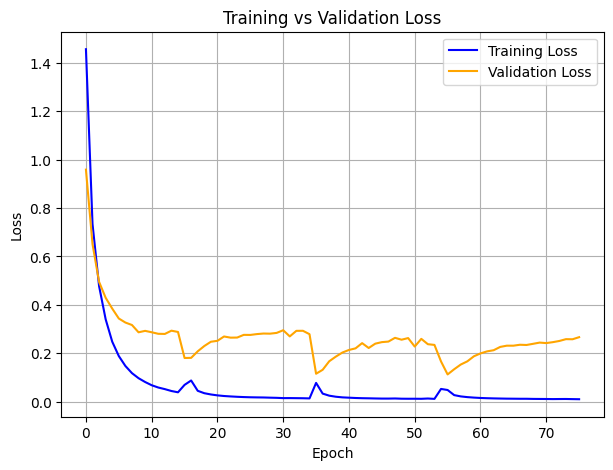

In [16]:
## Execution - STAGE-2 ONLY (Load pre-trained Stage-1)
from dataArrange import dataRearrange1

print("="*60)
print("STAGE-2 ONLY: Loading Pre-Trained Stage-1 Model")
print("="*60)

# Load pre-trained Stage-1 model
model_dir_stage1 = os.path.join("model", STAGE1_MODEL_DIR)
stage1_model_path = os.path.join(model_dir_stage1, f"unet1_fold_1.pt")

print(f"Pre-trained Stage-1 model path: {stage1_model_path}")
if not os.path.exists(stage1_model_path):
    print(f"ERROR: Stage-1 model not found at {stage1_model_path}")
    raise FileNotFoundError(f"Stage-1 model not found: {stage1_model_path}")

# Load Stage-1 model once
print("Loading Stage-1 model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
stage1_model = UNet(in_channels=IN_CHANNEL,
                   out_channels=11,
                   n_blocks=N_BLOCK,
                   start_filters=32,
                   activation='relu',
                   normalization='instance',
                   conv_mode='same',
                   dim=2).to(device)
stage1_model.load_state_dict(torch.load(stage1_model_path))
print("✓ Stage-1 model loaded successfully")
#stage1_model = None
# Prepare data splits
random_seed = 0
X = file_names_with_prefix(data_dir, 'N')
y_file_names = file_names_with_prefix(labeled_dir, 'N')
y = [label_group[:2] for label_group in y_file_names]

X = np.array(X)
y = np.array(y)

print(X)
print(y)

# Training transformations
transforms_training = ComposeDouble([
    FunctionWrapperDouble(create_dense_target, input=False, target=True),
    FunctionWrapperDouble(np.moveaxis, input=True, target=False, source=-1, destination=0),
    FunctionWrapperDouble(normalize_01)
])

transforms_val = ComposeDouble([
    FunctionWrapperDouble(create_dense_target, input=False, target=True),
    FunctionWrapperDouble(np.moveaxis, input=True, target=False, source=-1, destination=0),
    FunctionWrapperDouble(normalize_01)
])

if CROSS_VAL:
    skf = StratifiedKFold(n_splits=N_SPLIT, shuffle=True)
    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        if fold !=4:
            continue
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train, y_train, test_size=0.333333333, random_state=42, stratify=y_train)
        
        input_train = X_train_final
        input_name_val = X_val
        
        print("Cross validation: " + str(CROSS_VAL))
        print(f"Fold: {fold} out of {N_SPLIT}")
        print("Augmentation: " + str(AUGMENTED))
        if AUGMENTED:
            print("Augmentation amount: " + str(AUGMENTATION))
        print("Training: Total of " + str(len(input_train)) + " cases.")
        print(input_train)
        print("Validation: Total of " + str(len(input_name_val)) + " cases.")
        print(input_name_val)
        print("Test: Total of " + str(len(X_test)) + " cases.")  
        print(X_test)
        print()
        
        if AUGMENTED:
            repeated_items_train = np.repeat(input_train, AUGMENTATION)
            suffixes_train = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_train))
            input_train = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_train, suffixes_train)])
            input_train = np.array(dataRearrange1(input_train, AUGMENTATION))
            
            repeated_items_val = np.repeat(input_name_val, AUGMENTATION)
            suffixes_val = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_val))
            input_name_val = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_val, suffixes_val)])
        
        input_dataset, label_dataset = CreateWeightImage(input_train, augmentation=AUGMENTED)
        input_dataset_val, label_dataset_val = CreateWeightImage(input_name_val, augmentation=AUGMENTED)
        
        # Call Learn_EA with pre-trained Stage-1 model
        Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
                 0, fold, next_model=False, model_n="unet2", inChannels=57,
                 stage1_model_path=stage1_model_path, stage1_model_loaded=stage1_model)
        
        mConv_predict(X_test, fold, stage1_model_path=stage1_model_path)
        
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED)
    X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train, y_train, test_size=0.333333333, random_state=42, stratify=y_train)
    
    input_train = X_train_final
    input_name_val = X_val
    
    print("Cross validation: " + str(CROSS_VAL))
    print("Augmentation: " + str(AUGMENTED))
    if AUGMENTED:
        print("Augmentation amount: " + str(AUGMENTATION))
    print("Training: Total of " + str(len(input_train)) + " cases.")
    print(input_train)
    print("Validation: Total of " + str(len(input_name_val)) + " cases.")
    print(input_name_val)
    print("Test: Total of " + str(len(X_test)) + " cases.")  
    print(X_test)
    print()
    
    if AUGMENTED:
        repeated_items_train = np.repeat(input_train, AUGMENTATION)
        suffixes_train = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_train))
        input_train = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_train, suffixes_train)])
        input_train = np.array(dataRearrange1(input_train, AUGMENTATION))
            
        repeated_items_val = np.repeat(input_name_val, AUGMENTATION)
        suffixes_val = np.tile(np.arange(1, AUGMENTATION + 1), len(repeated_items_val))
        input_name_val = np.array([f"{item}-{suffix}" for item, suffix in zip(repeated_items_val, suffixes_val)])
    
    input_dataset, label_dataset = CreateWeightImage(input_train, augmentation=AUGMENTED)
    input_dataset_val, label_dataset_val = CreateWeightImage(input_name_val, augmentation=AUGMENTED)
    
    # Call Learn_EA with pre-trained Stage-1 model
    Learn_EA(input_dataset, label_dataset, input_dataset_val, label_dataset_val, 
             0, fold=0, next_model=False, model_n="unet2", inChannels=57,
             stage1_model_path=stage1_model_path, stage1_model_loaded=stage1_model)
    
    mConv_predict(X_test, fold=0, stage1_model_path=stage1_model_path)
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()